In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.linalg import solve_discrete_are
from pykoopman import observables, regression
from KRTB_pyKoopman import KoopmanModelTrainer, KoopmanAnalysis, integralRK4
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

## Generate Trainig Dataset and Train EDMD

#### Load configurations

In [2]:
curdir = os.path.dirname("controlled_VDP.ipynb")
config_path = os.path.join(curdir, "configs", "benchmark_ASR_forward.json")
stream = print

#### Simulate traning data

In [3]:
def genControlCmd(n_sample, t_vec):
    T = len(t_vec)
    u = np.zeros((n_sample, T, 2))

    for i in range(n_sample):
        a = np.zeros(T)
        delta = np.zeros(T)

        for k in range(1, T):
            a[k] = 0.95 * a[k-1] + 0.1 * np.random.randn()
            delta[k] = 0.95 * delta[k-1] + 0.05 * np.random.randn()

        u[i, :, 0] = np.clip(a, -1.0, 1.0)
        u[i, :, 1] = np.clip(delta, -0.4, 0.4)

    return u
    
# t = np.arange(0, 2, 0.05)
# u = genControlCmd(10, t)
# print(u.shape)
# for i in range(2):
#     plt.plot(t, u[i, :, 1])
# plt.show()

In [4]:
use_saved_data = False
kmt = KoopmanModelTrainer(config_path, curdir, save_model=True, save_sim_data=True, stream=stream)

if use_saved_data:
    states, controls, t_vec = kmt.loadSimTrajectories(control=True)
    # pk_model = kmt.loadPyKoopmanModel()
else:
    states, controls, t_vec = kmt.simTrajWithControl(genControlCmd, seed=4)
    controls_lifted = controls.copy()
    controls_lifted[:, :, 1] = np.tan(controls[:, :, 1])

Simulating trajectories ...
Simulation is Done!
Generating Simulated Trajectory to Train a Koopman Model
 Num. simulated trajectories: 10000
 Random seed: 4
 State bounds: 
  x1: [-2, 2]
  x2: [-2, 2]
  x3: [-3.141592653589793, 3.141592653589793]
  x4: [-1, 1]

 Simulation time span (sec): 5.000 [0.000, 5.000] 
 Time step(sec): 0.05 
 Process runtime (sec): 2.065
 Simulated trajectories are stored at: sim_trajectories/benchmark_ASR_forward.npz


#### Plot some simulated trajectories

[ 1.11753169 -0.0307647  -0.94613131  0.2935787 ]


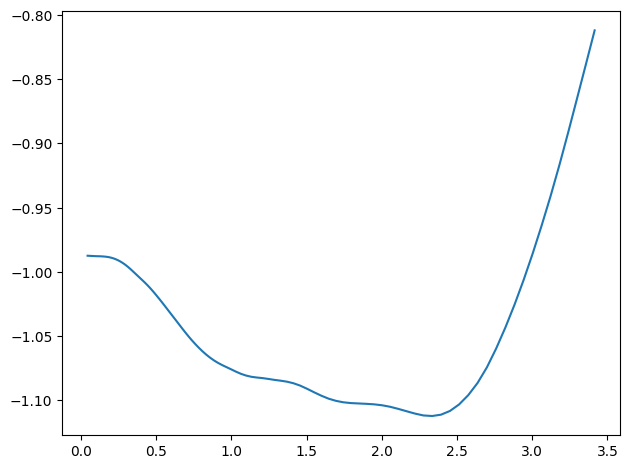

In [5]:
# rand_num = np.random.randint(0, 5000, 5)
rand_num = [220]
fig, ax = plt.subplots()
for i in rand_num:
    ax.plot(states[i, :, 0], states[i, :, 1])
print(states[10, 0, :])

plt.tight_layout()
plt.show()

#### train EDMD Model

In [6]:
# normalize states
# x_mean = states.mean(axis=(0,1))
# x_std = states.std(axis=(0,1)) + 1e-8

# mx, my, mth, mv = x_mean
# sx, sy, sth, sv = x_std

# Normalize states BEFORE Koopman
# states_norm = states.copy()
# states_norm[..., 0] = (states[..., 0] - mx) / sx   # px
# states_norm[..., 1] = (states[..., 1] - my) / sy   # py
# states_norm[..., 2] = states[..., 2]               # theta (periodic)
# states_norm[..., 3] = (states[..., 3] - mv) / sv   # v

In [7]:
obs = observables.CustomObservables(
        observables=[
            # --- CONSTANT TERM ---
            # lambda px, py, th, v: 1.0, # aleady exist in CustomObservables

            # --- ANGLE FEATURES ---
            lambda px, py, th, v: np.sin(th),
            lambda px, py, th, v: np.cos(th),

            # --- SECOND ORDER ---
            lambda px, py, th, v: px**2,
            lambda px, py, th, v: py**2,
            lambda px, py, th, v: px * py,

            lambda px, py, th, v: px * v,
            lambda px, py, th, v: py * v,

            lambda px, py, th, v: v**2,
        ]
    )

if use_saved_data:
    pk_model = kmt.loadPyKoopmanModel()
else:
    reg = regression.EDMDc()
    pk_model = kmt.trainPyKoopmanModel(states, controls=controls_lifted,
                                       regressor=reg, observables=obs)

Training a pyKoopman Model based on Simulated Trajectories

 Process runtime (sec): 0.410473
 Trained model is stored at: sim_trajectories/benchmark_ASR_forward.npz


#### EDMD trajectory Simulation

/home/ali/my_ws/Thesis/venv/lib/python3.10/site-packages/pykoopman/koopman.py:302: ComplexWarning: Casting complex values to real discards the imaginary part
  x = x.astype(self.A.dtype)


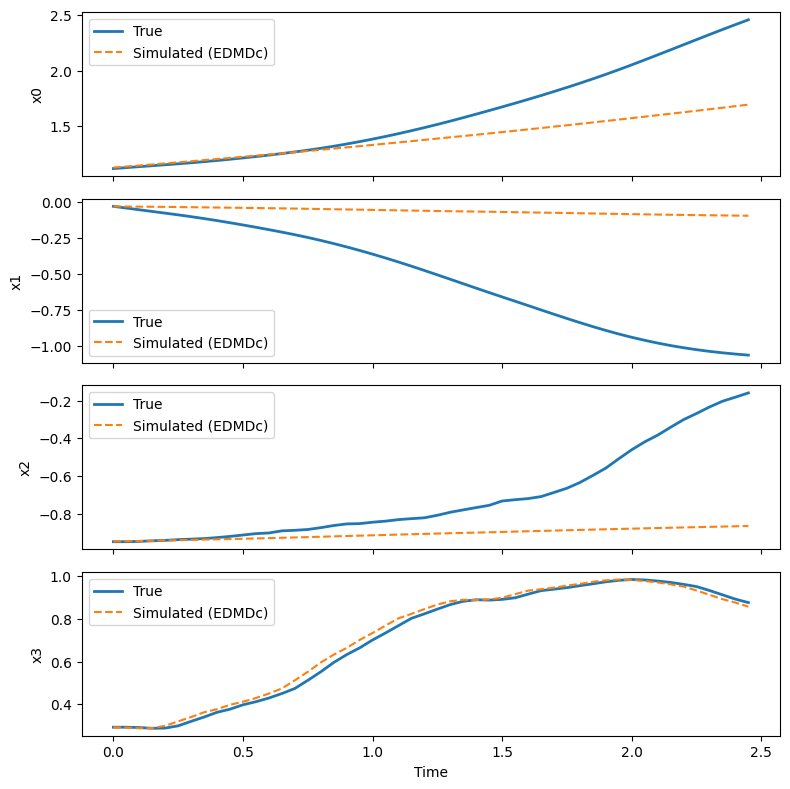

In [8]:
idx = 10
n_ss = 50

X_true = states[idx, :n_ss]
traj_u = controls[idx, :n_ss]
x0 = X_true[0]

X_sim = pk_model.simulate(x0, traj_u, n_ss)

t = t_vec[:X_sim.shape[0]]
n_states = X_true.shape[1]
fig, axs = plt.subplots(n_states, 1, figsize=(8, 2*n_states), sharex=True)

for i in range(n_states):
    axs[i].plot(t, X_true[:, i], label="True", linewidth=2)
    axs[i].plot(t, X_sim[:, i], "--", label="Simulated (EDMDc)")
    axs[i].set_ylabel(f"x{i}")
    axs[i].legend()

axs[-1].set_xlabel("Time")
plt.tight_layout()
plt.show()

## Controller Design

#### PD controller

In [9]:
def pd_controller(x, x_ref, kp=2.0, kd=1.0, umax=1.0):
    x1, x2 = x.squeeze()
    r1, r2 = x_ref
    u = kp*(r1 - x1) + kd*(r2 - x2)
    return np.clip(u, -umax, umax).reshape(-1, 1)

#### LQR Controller

In [10]:
def dlqr(A, B, Q, R):
    P = solve_discrete_are(A, B, Q, R)
    K = np.linalg.inv(B.T @ P @ B + R) @ (B.T @ P @ A)
    return K, P

def norm_state(x):
    xn = x.copy()
    xn[0] = (xn[0] - mx) / sx
    xn[1] = (xn[1] - my) / sy
    xn[2] = xn[2]                  # keep theta raw (as you trained)
    xn[3] = (xn[3] - mv) / sv
    return xn

def koopman_lqr_u(x, x_ref, umax=np.array([1.0, 0.4])):
    # x_n = norm_state(x.squeeze())
    # x_ref_n = norm_state(x_ref.squeeze())
    z = pk_model.observables.transform(x.reshape(1, -1))
    z_ref = pk_model.observables.transform(x_ref.reshape(1, -1))

    # Solve B u ≈ (I - A) z_ref
    rhs = (np.eye(A.shape[0]) - A) @ z_ref.T
    u_ref, *_ = np.linalg.lstsq(B, rhs, rcond=None)   # (2,1)
    u_ref = u_ref.squeeze()
    
    dz = (z - z_ref).T
    u_tilde = (u_ref.reshape(-1, 1) - K @ dz).reshape(1, -1) 
    # saturation in lifted space
    u_tilde = np.clip(u_tilde, -umax, umax).squeeze()

    a = u_tilde[0]
    delta = np.arctan(u_tilde[1])
    
    return np.array([a, delta]).reshape(1, -1)

#### Test PD controller to move from state A to B

In [11]:
x_a = np.array([1.68, 1.16])
x_b = np.array([-1.65, 0.3])
dt = 0.05
N = 100

U = np.zeros(N)
X = np.zeros((N, 2))
x = x_a.reshape(1, -1)
for k in range(N):
    u = pd_controller(x.squeeze(), x_b, kp=4, kd=2, umax=10)
    x = integralRK4(kmt.system.ff, np.asarray(x).reshape(1, -1), np.asarray(u).reshape(1, -1), dt)
    U[k] = u.squeeze()
    X[k, :] = x
    if np.linalg.norm(x - x_b) < 0.1:
        print(f'break at {k}')
        break

fig, axs = plt.subplots(2, 1, figsize=(5, 10))
axs[0].plot(X[:, 0], X[:, 1], '--b')
axs[0].plot(x_b[0], x_b[1], 'or')
axs[0].plot(x_a[0], x_a[1], 'og')
axs[1].plot(np.arange(N), U, '-g')
plt.show()

IndexError: index 2 is out of bounds for axis 1 with size 2

#### Test LQR controller to move from state A to B

In [26]:
A = pk_model.A 
B = pk_model.B
C = pk_model.C
nz = A.shape[0]

Qx = np.diag([10.0, 10.0, 5.0, 1.0])
Q = C.T @ Qx @ C + 1e-6*np.eye(nz)
R = np.diag([
    1.2, # acceleration penalty
    2.1 # steering penalty
]) # tune this

K, _ = dlqr(A, B, Q, R)
print(np.linalg.norm(K))

63590.50831922606


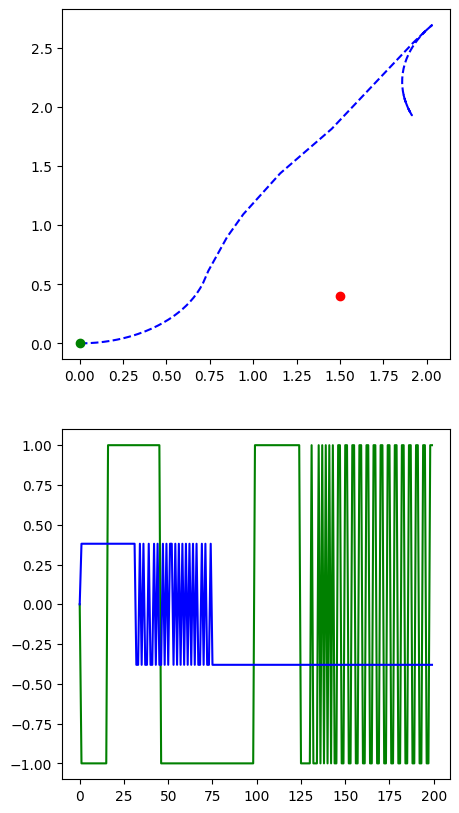

In [27]:
E = N = 200
dt = 0.05

X = np.zeros((N, 4))
U = np.zeros((N, 2))

x = np.array([0.0, 0.0, 0.0, 1.0])

x_ref = np.array([[1.5, 0.4, np.pi/4, 1.0]])

X[0] = x

for k in range(1, N):
    u = koopman_lqr_u(x, x_ref, umax=np.array([1, 0.4]))
    x = integralRK4(kmt.system.ff, x.reshape(1, -1), u, dt)

    X[k] = x
    U[k] = u
    if np.linalg.norm(x[:2] - x_ref[:2]) < 0.2:
        print(f"Reached target at step {k}")
        E = k + 1
        break

fig, axs = plt.subplots(2, 1, figsize=(5, 10))
axs[0].plot(X[:E, 0], X[:E, 1], '--b')
axs[0].plot(x_ref[0, 0], x_ref[0, 1], 'or')
axs[0].plot(0, 0, 'og')
axs[1].plot(np.arange(E), U[:E, 0], '-g')
axs[1].plot(np.arange(E), U[:E, 1], '-b')
plt.show()



## Extraxt Eigenfunctions

#### Validate eigenfunctions

In [15]:
pk_model.continuous_lamda_array
kAnalysis = KoopmanAnalysis(config_path, pk_model, stream=stream)
kAnalysis.listEigVal()
_, valid_idx = kAnalysis.eigFunValidity(states, t_vec, alpha=1, score_threshold=2)

Continuous Eigenvales

 eig_v 0 = 0.405+0.000j
 eig_v 1 = 0.355+0.000j
 eig_v 2 = 0.308+0.129j
 eig_v 3 = 0.308-0.129j
 eig_v 4 = 0.025+0.000j
 eig_v 5 = 0.196+0.101j
 eig_v 6 = 0.196-0.101j
 eig_v 7 = 0.152+0.011j
 eig_v 8 = 0.152-0.011j
 eig_v 9 = 0.177+0.000j
 eig_v 10 = 0.166+0.000j
 eig_v 11 = -0.000+0.000j
Pykoopman Validity Check

Eigenfunction scores based on linearity and invariant error:
[ 748.5372794  1063.97992544   20.80185849   20.80185849   77.75751479
   14.90172772   14.90172772   12.55675205   12.55675205  200.7953152
  488.49784159  508.6934416 ]

Eigenfunction ranking (best to worst):
[ 7  8  5  6  2  3  4  9 10 11  0  1]

Chosen eigenfunction indices: 
[]
 Process runtime (sec): 2.650493


Reach-Time bound Analysis

Status: ('PROBABLY REACHABLE', 1)
Reach-time bounds (time intervals when trajectory is in target set):
  Interval 1: [0.000000, 1.528293]

Process time: 0.124034
Result of reachability with simulation

All trajectories reach the target set with in time bound [0.000, 0.000]
 Process runtime (sec): 0.111499


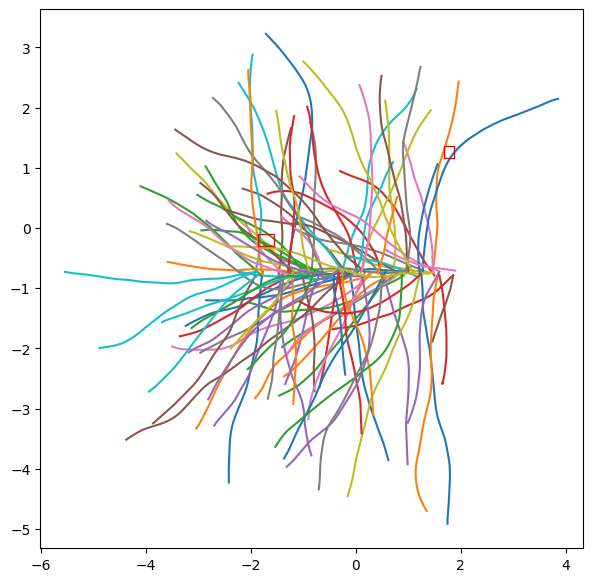

In [16]:
# init_sets = [[1.68, 1.88],[2.16, 2.36]]
# tar_sets = [[0, 0.2],[-2.16, -1.96]]

kAnalysis.timeReachBound(valid_ef_idx=np.array([0, 1, 2, 3]), n_samples=1000)
tested_traj = kAnalysis.verifyReachabilityWithSim_c(genControlCmd=genControlCmd, 
                                                    n_samples=100, final_time=4, deltaT=0.01)

fig, ax = plt.subplots(figsize=(7, 7))
a = 0.2
rect1 = patches.Rectangle((1.68, 1.16), a, a, edgecolor='r', facecolor='none', zorder=3)
rect2 = patches.Rectangle((-1.85, -0.3), 0.3, a, edgecolor='r', facecolor='none', zorder=3)
ax.add_patch(rect1)
ax.add_patch(rect2)

for traj in tested_traj:
    ax.plot(traj[:, 0], traj[:, 1])

plt.show()